
<br/>
<b>Última actualización</b>:12 de septiembre


In [ ]:
!pip install -q gdown

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
from scipy.interpolate import interp1d

from scipy.stats import norm


In [ ]:
import random
from scipy import optimize
import seaborn as sns

# **Curva de rotación de una Galaxia**

Una buena aproximación al movimiento de las estrellas en las galaxias espirales, es que las estrellas en el disco se mueven siguiendo órbitas circulares. Estas órbitas circulares tienen una velocidad circular que
varía con la distancia al centro $V_c(R)$.
Las observaciones permiten obtener información de la curva de rotación de la galaxia, que corresponde a la medición de la velocidad circular de la galaxia en la forma de pares de datos R (Distancia al centro) y
$V_c(R)$ velocidad circular a ese radio.

Un modelo con el que se puede describir estas observaciones está dado por:

$$
V_{c}(R)=\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}
$$

$$
V_{c d}^{2}(R)={\frac{G M_{d}R}{[R^{2}+(a+b)^{2}]^{3/2}}}
$$

$$
V_{c h}^{2}(R)=\frac{G M_{h}R}{(R+r_{s})^{2}}
$$

Donde $M_d$, $M_h$ y $r_s$ son parámetros libres del modelo y $a = 7$ y $b = 0.5$. ($M_d$ representa la masa del disco,
$M_h$ la masa del halo y $r_s$ la escala de tamaño del halo de la galaxia)
La tabla de datos anexa tiene la curva de rotación observada para una galaxia espiral real. Los datos son($R_i$, $V_c$,$i$, $σ_i$). La primera columna es $R_i$ en Kpc y la segunda columna es $V_c$,$i$ medida en km/s y la tercera es el error en $V_c$,$i$ también medido en km/s.

## **Unidades canonicas**

Recomiendo que usen un sistema de unidades en el que la constante gravitacional G = 43007.1. En ese
sistema de unidades, se tiene que:
- Unidad de masa = 1010Msun
- Unidad de longitud = 1Kpc
- Unidad de tiempo = 1.1Gyr
- Unidad de velocidad = 1km/s

In [ ]:
G=43007.1
UM=1e10 #Msun
UL=1 #Kpc
UT=1.1 #Gyr
UV=1 #km/s

## **Tabla de datos**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta='/content/drive/MyDrive/AstroEstadistica/experimental_data_caida.dat'

In [ ]:
# Leer el archivo con Pandas
data = pd.read_csv(ruta, delimiter='\s+')  # Ajusta el delimitador si es necesario

# Cambiar el nombre de las columnas
nuevos_nombres = ['Distancia [Kpc]', 'Velocidad [km/s]', 'Error [km/s]']  # Reemplaza con los nombres deseados
data.columns = nuevos_nombres


In [ ]:
data

,Distancia [Kpc],Velocidad [km/s],Error [km/s]
0,0.09,114.58,18.500
1,0.19,130.28,8.200
2,0.30,132.77,19.630
3,0.42,135.07,8.390
4,0.56,140.83,19.080
5,0.70,152.06,28.900
6,0.86,162.64,4.773
7,1.04,168.68,28.320
8,1.23,171.57,17.170
9,1.45,173.31,10.790


##**Primer Punto**

Utilice el formalismo Bayesiano para estimar las distribuciones posteriores para Md, Mh y rs. Tenga
en cuenta las siguientes consideraciones:


Del formalismo bayesiao se tiene :
$$P(\vec{\theta}|M)=\frac{P(M|\vec{\theta})P(\vec{\theta})}{P(M)}$$

###**Likelihood**


- Considere que las incertidumbres en las medidas de la velocidad circular de las galaxias se distribuye
gausianamente.


$$P(M|\vec{\theta})=\prod_{i=1}^{n}f(\epsilon _i)$$

$$P(M|\vec{\theta})=\prod_{i=1}^{n}f(\epsilon _i)$$


$$P(M|\vec{\theta})=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi \sigma^{2}}}e^{\frac{-\epsilon _i^{2}}{2\sigma^{2}}}$$

Usemos:

$$\epsilon _i=V_{c,i}-V_{c}(R)$$

$$\boxed{\epsilon _i=V_{c,i}-\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}}$$

### **Priors**


Los prios al ser un estado de información previa se evalua según lo que se haya estudiado de mi problema en cuestión. Siempre hay una forma de cuantificar o modelar mi prior, de este modo, tomemos como prior nulo o no informativo el hecho de que mis parametros siguen una distribución uniforme, donde a su vez estan restringidos por hyperparams.

In [ ]:
#Datos como arreglos
err=np.array(data.iloc[:, 2]) #COLUMNAS
V_ci=np.array(data.iloc[:, 1])
R_i=np.array(data.iloc[:, 0])

In [ ]:
#Longitud de mis arregos
NDATA=len(R_i)
NDATA

32

$$
V_{c}(R)=\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}
$$

$$
V_{c d}^{2}(R)={\frac{G M_{d}R}{[R^{2}+(a+b)^{2}]^{3/2}}}
$$

$$
V_{c h}^{2}(R)=\frac{G M_{h}R}{(R+r_{s})^{2}}
$$

Haciendo un analisis sobre las incertidumbres se puede observar que se puede aproximar los valores de errores a un valor promedio.

In [ ]:
#Promedio para cada error.
sigman = []
for i in range(len(R_i)):
    sigman.append(np.mean(err))

sigma = np.array(sigman)
sigma

array([18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875, 18.4981875, 18.4981875, 18.4981875,
       18.4981875, 18.4981875])

In [ ]:
len(sigma)

32

### **Primera visualización de los datos**

In [ ]:

def model1(R,Md,Mh,rs):
  a=7
  b=0.5
  G = 43007.1
  v_ch=(G*Md*R)/((R**(2)+(a+b)**(2)))**(3/2)
  v_cd=(G*Mh*R)/((R+rs)**(2))
  vc = np.sqrt((v_ch)+(v_cd))
  return vc


In [ ]:
mdata = np.empty(len(R_i))
for i in range(NDATA):
        mdata[i] = model1(R_i[i],Md=6,Mh=30,rs=15)

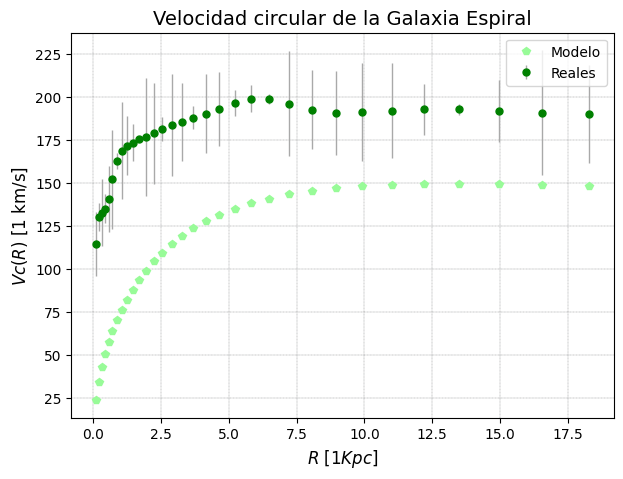

In [ ]:
plt.figure(figsize=(7,5))
plt.errorbar(R_i, V_ci,yerr=err,lw=0,elinewidth=1,ecolor='darkgrey', fmt='go',markersize=5,label = 'Reales')
plt.plot(R_i,mdata, "p", color = 'palegreen',label = 'Modelo')
#plt.plot(R_i, V_ci, "o", color = '#27AE60', label = 'Reales')
plt.title("Velocidad circular de la Galaxia Espiral",fontsize=14)
plt.xlabel("$R$ [$1 Kpc$]",fontsize=12)
plt.ylabel("$Vc(R)$ [1 km/s]",fontsize=12)

plt.grid(color='#414446', linestyle='--', linewidth=0.2)
plt.legend()
plt.show()

AL observar esto puedo decir que la eleccion de los parametros es crucial para ajustar mi evidencia a el modolo, nnuestro primer paso sera utilizar un ajuste o curvfit para obtener una primera aproximacion de mis mejores parametros, para finalmente usar formalismo bayesiano y tener mis parametros mas acertados.

**AL intentar inicialmente utilizar el primer likehood donde solo tenia en cuenta la parte Gaussiana se encontro que el costo computacional era alto pues se demorarab 4 minutos para obtener el 1 valor de MAP para cada parametro, asi que se opto por cambiar la forma del likelihood y se siguio como se trabajo en clase , donde se tuvieron las siguientes consideraciones:**

In [ ]:
def kerneli(R, Vc, sigma, Md, Mh, rs):
    mi = f_model(R,Md,Mh,rs)
    fac = np.abs(Vc - mi)*np.abs(Vc - mi)#Aca es donde yo lo puedo variar como se me de la gana
    if ((Vc > mi-sigma ) and (Vc < mi+sigma)):
        if mi-sigma < 0:
            ml = 0.0
        else:
            ml = mi-sigma

        window = (1.0 - fac/(sigma*sigma))*np.random.uniform(ml, mi+sigma)
    else:
        window = 0.0

    return window


In [ ]:
def likelihood(r, Vc, sig, Md, Mh, rs):
    like = 1.0
    for i in range(len(r)):  # Iterate through the length of the arrays
        value = kerneli(r[i], Vc[i], sig[i], Md, Mh, rs)
        if value >= 0:
            like *= value
    return like

In [ ]:
a = 7
b = 0.5
def f_model(Rd, Md, Mh, rs):
    return np.sqrt((G*Mh*Rd)/((Rd+rs)**2)+(G*Md*Rd)/(Rd*Rd+(a+b)**2)**(2/3))

####**Optimización**

In [ ]:
vGuess = [2,10,8]
vTrial, aCova = optimize.curve_fit(f_model, R_i, V_ci, vGuess)
e1, e2, e3 = vTrial
e1,e2,e3

<ipython-input-20-2494445da464>:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((G*Mh*Rd)/((Rd+rs)**2)+(G*Md*Rd)/(Rd*Rd+(a+b)**2)**(2/3))


(2.1760113058575605, 1.7935905272002048, 0.8783819964569629)

In [ ]:
Md, Mh, rs = e1,e2,e3

In [ ]:
likelihood_vector = np.empty(32)
for i in range(len(R_i)):
        likelihood_vector[i] = kerneli(R_i[i], V_ci[i], sigma[i], Md, Mh, rs)

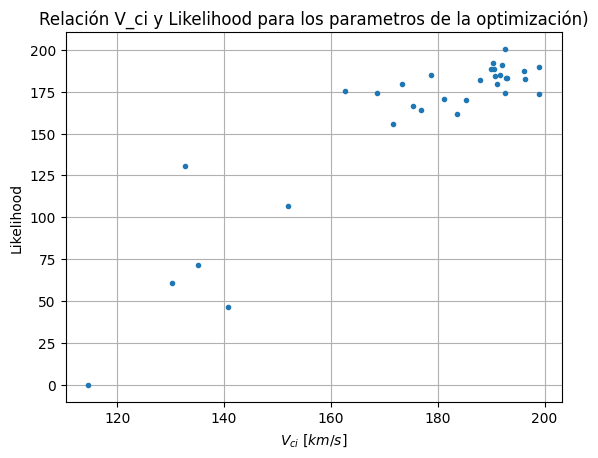

In [ ]:
plt.plot(V_ci, likelihood_vector, ".")
plt.xlabel(r"$V_{ci}$ $[km/s]$")
plt.ylabel("Likelihood")
plt.title("Relación V_ci y Likelihood para los parametros de la optimización)")
plt.grid(True)  # Agrega la grilla al gráfico
plt.show()

In [ ]:
Md_mina = 1e9/UM
Md_maxa = 1e11/UM
Mh_mina = 1e10/UM
Mh_maxa = 1e12/UM
rs_mina = 1
rs_maxa = 50
Mh_mina,Mh_maxa


(1.0, 100.0)

In [ ]:
Md_SAMPLES = 50
Mh_SAMPLES = 50
rs_SAMPLES = 50

#df = open("parameters.dat","w")

MD = []
MH = []
RS = []

for n in range(60):
    Md_min = 0.1+(0.005*n)
    Mh_min = 0.1+(0.005*n)
    rs_min = 0.1+(0.005*n)
    dMd = (Md+(0.005*n)-Md_min)/(1.0*Md_SAMPLES)
    dMh = (Mh+(0.005*n)-Mh_min)/(1.0*Mh_SAMPLES)
    drs = (rs+(0.005*n)-Mh_min)/(1.0*Mh_SAMPLES)

    Md = Md_min
    Mdvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)
    Mhvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)
    rsvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)

    likevector = np.empty(Md_SAMPLES*Md_SAMPLES*rs_SAMPLES)
    count = 0
    for k in range(Md_SAMPLES):
        Mh = Mh_min
        for l in range(Md_SAMPLES):
          rs = rs_min
          for m in range(Md_SAMPLES):
            Mdvector[count] = Md
            Mhvector[count] = Mh
            rsvector[count] = rs
            value = likelihood(R_i, V_ci, sigma, Md, Mh, rs)
            #df.write("%16.8f %16.8f %16.8f %16.8e\n" %(Mdvector[count], Mhvector[count], rsvector[count], value) )
            likevector[count] = value
            rs = rs+drs
            count = count+1
          Mh = Mh+dMh
        Md = Md+dMd
        mde, mhe, rse = Mdvector[likevector.argmax()], Mhvector[likevector.argmax()],rsvector[likevector.argmax()]
    print(mde,mhe,rse)
    MD.append(mde)
    MH.append(mhe)
    RS.append(rse)
#df.close()

2.3536561451944915 1.2067922353287255 0.6343818884917386
2.3586561451944914 1.1892046386893635 0.6161478933399238
2.3679561451944924 1.2216922353287254 0.6372648909158319
2.381556145194493 1.236492235328727 0.6393478933399243
2.3994561451944945 1.2330046386893647 0.6453308957640166
2.368245537166715 1.1864418487712782 0.6170629054603871
2.3403349291389355 1.2380294454106398 0.6415629054603876
2.4244455371667133 1.2212542521319163 0.6425289103085731
2.458845537166712 1.1555038655744698 0.6157609200049438
2.385424321111156 1.2186914622138314 0.6319439224290369
2.3695137130833763 1.2335038655744703 0.6335099272772227
2.3556031050555992 1.194241075656385 0.6171589345495011
2.402403105055601 1.2691286722957467 0.6518589345495011
2.3927924970278203 1.2589534790170238 0.6504249393976858
2.3843818890000423 1.152315495820216 0.605056949094056
2.3768712809722636 1.1676278991808533 0.6173399515181484
2.369960672944482 1.2522154958202165 0.6523399515181488
2.297339456888924 1.3068154958202178 0.66

- Muestre gráficamente como es la distribución de probabilidad posterior P(Md), P(Mh) y P(rs).


In [ ]:
MD60 = MD[0:60]


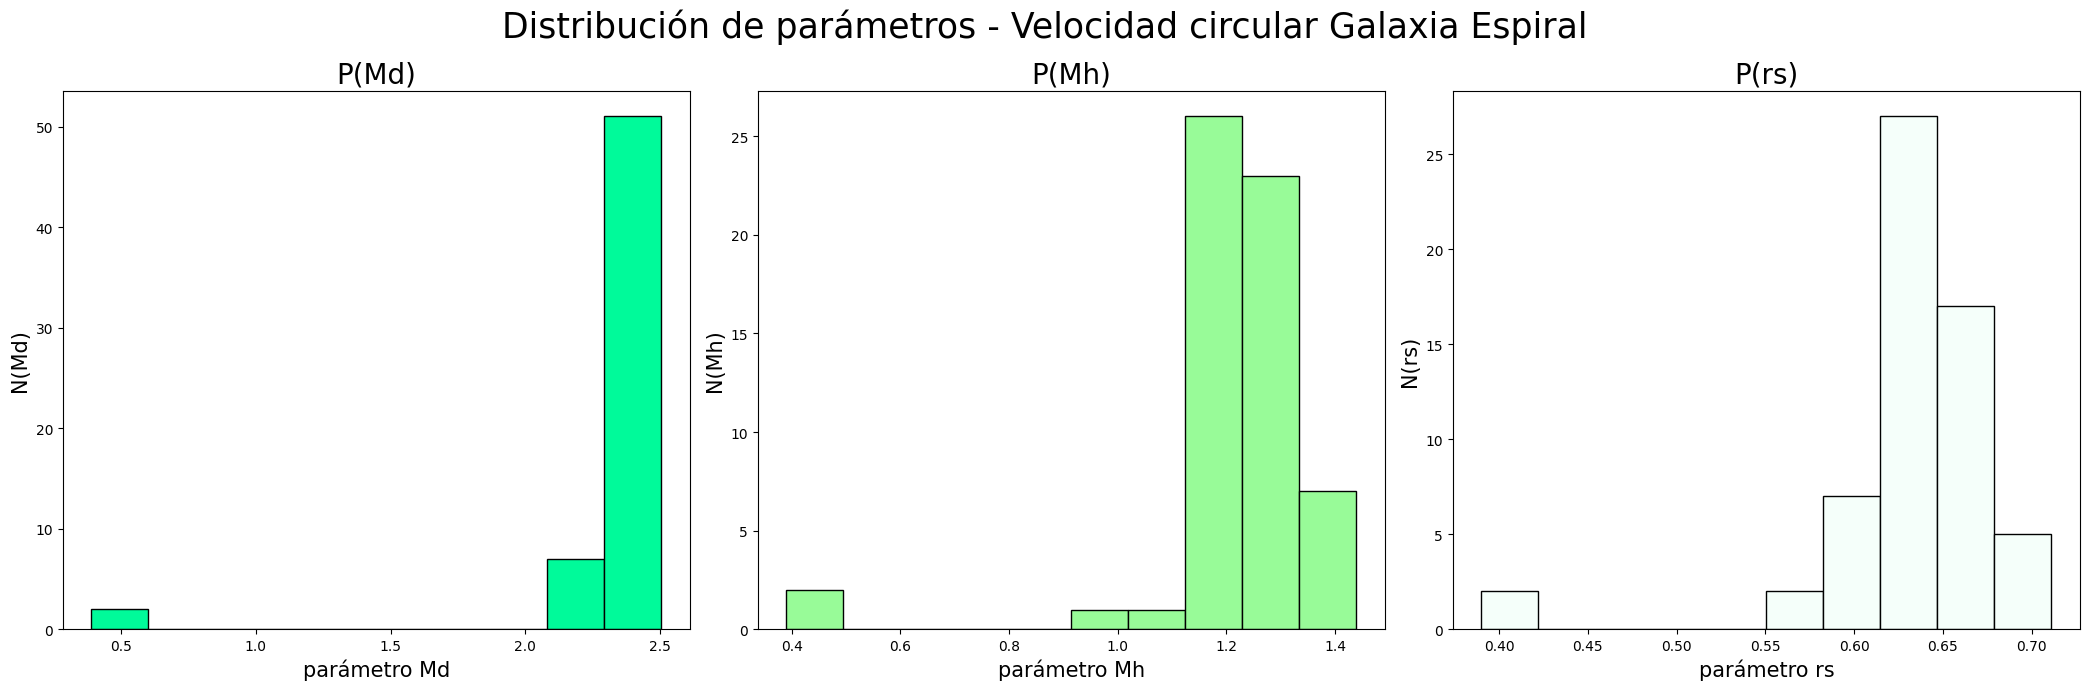

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

# Histograma para Md
ax[0].hist(MD60, bins=10, color='mediumspringgreen', edgecolor='black')
ax[0].set_xlabel('parámetro Md', size=15)
ax[0].set_ylabel('N(Md)', size=15)
ax[0].set_title('P(Md)', size=20)

# Histograma para Mh
ax[1].hist(MH[0:60], bins=10, color='palegreen', edgecolor='black')
ax[1].set_xlabel('parámetro Mh', size=15)
ax[1].set_ylabel('N(Mh)', size=15)
ax[1].set_title('P(Mh)', size=20)

# Histograma para rs
ax[2].hist(RS[0:60], bins=10, color='mintcream', edgecolor='black')
ax[2].set_xlabel('parámetro rs', size=15)
ax[2].set_ylabel('N(rs)', size=15)
ax[2].set_title('P(rs)', size=20)
fig.suptitle('Distribución de parámetros - Velocidad circular Galaxia Espiral', fontsize=25)  # Título para toda la figura

plt.tight_layout()  # Ajusta el espaciado entre subgráficos para que no se solapen
plt.savefig("parametros_histogramas.png")  # Guarda la figura como imagen
plt.show()


- Entregue una estimaci ́on para el valor de cada uno de los par ́ametros del modelo (Md, Mh y rs) y
entregue barras de error. Explique como hizo su estimaciones y justif ́ıquelas.

In [ ]:
MD60=np.array(MD60)
MH_re=np.array(MH[0:60])
RS_re=np.array(RS[0:60])


In [ ]:
MAP_Md,MAP_Mh,MAP_rs=MD60.mean(),MH_re.mean(),RS_re.mean()
MAP_Md,MAP_Mh,MAP_rs

(2.2980532041384554, 1.2094673977735841, 0.6299676165879243)

In [ ]:
np.std(MD60),np.std(MH_re),np.std(RS_re)

(0.35851687851010694, 0.17171617839433428, 0.05214427554975896)

In [ ]:
mdata2 = np.empty(len(R_i))
for i in range(NDATA):
        mdata2[i] = model1(R_i[i],MAP_Md,MAP_Mh,MAP_rs)

In [ ]:
mdataf = np.empty(len(R_i))
for i in range(len(R_i)):
        mdataf[i] = err[i]

<ipython-input-38-80b7be7d46cf>:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go" (-> color='g'). The keyword argument will take precedence.
  plt.errorbar(R_i, V_ci,yerr=mdataf,lw=0,elinewidth=1,color='springgreen',ecolor='darkgrey', fmt='go',markersize=5,label = 'Datos Experimentales')


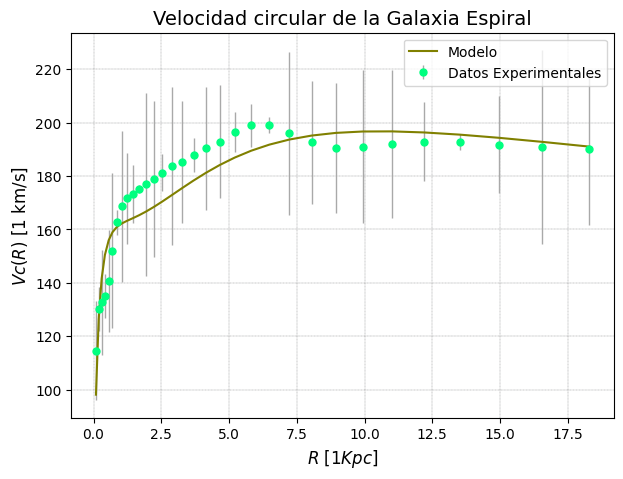

In [ ]:
plt.figure(figsize=(7,5))
plt.errorbar(R_i, V_ci,yerr=mdataf,lw=0,elinewidth=1,color='springgreen',ecolor='darkgrey', fmt='go',markersize=5,label = 'Datos Experimentales')
plt.plot(R_i,f_model(R_i,MAP_Md,MAP_Mh,MAP_rs),color='olive',label = 'Modelo')

#plt.plot(R_i, V_ci, "o", color = '#27AE60', label = 'Reales')
plt.title("Velocidad circular de la Galaxia Espiral",fontsize=14)
plt.xlabel("$R$ [$1 Kpc$]",fontsize=12)
plt.ylabel("$Vc(R)$ [1 km/s]",fontsize=12)

plt.grid(color='#414446', linestyle='--', linewidth=0.2)
plt.legend()
plt.show()